### Autograd Engine

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
class Value:
    _counter = 0

    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._id = Value._counter
        Value._counter += 1

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, exponent):
        assert isinstance(exponent, (int, float)), "only constant exponents are supported"
        out = Value(self.data ** exponent, (self,), f'**{exponent}')

        def _backward():
            self.grad += (exponent * self.data ** (exponent - 1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other ** -1

    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __rsub__(self, other): return Value(other) + (-self)
    def __rtruediv__(self, other): return Value(other) * self ** -1

    def exp(self):
        e = np.exp(self.data)
        out = Value(e, (self,), 'exp')

        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out

    def log(self):
        out = Value(np.log(self.data), (self,), 'log')

        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s = 1.0 / (1.0 + np.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')

        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'relu')

        def _backward():
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo, visited = [], set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def zero_grad(self):
        """Reset .grad to 0 across this whole graph so it can be reused."""
        visited = set()

        def _zero(v):
            if v not in visited:
                visited.add(v)
                v.grad = 0.0
                for child in v._prev:
                    _zero(child)
        _zero(self)

    def to_nx_graph(self):
        graph = nx.DiGraph()
        visited = set()

        def build_nx(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    graph.add_edge(child._id, v._id)
                    build_nx(child)
                graph.nodes[v._id]['label'] = f"{v._op} {v.data:.2f}"

        build_nx(self)
        return graph

### Checking Derivatives of Activations Fn 

In [10]:
def numerical_grad(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

def check(name, f, x0):
    v = Value(x0)
    out = f(v)
    out.backward()
    num = numerical_grad(lambda x: f(Value(x)).data, x0)
    print(f"{name:8s}  analytic={v.grad: .6f}   numerical={num: .6f}")

check("exp",     lambda x: x.exp(),                    0.7)
check("log",     lambda x: x.log(),                    2.3)
check("tanh",    lambda x: x.tanh(),                   0.4)
check("sigmoid", lambda x: x.sigmoid(),                -1.1)
check("relu",    lambda x: x.relu(),                   2.0)
check("div",     lambda x: (x + 1) / (x ** 2 + 2),     1.5)

exp       analytic= 2.013753   numerical= 2.013753
log       analytic= 0.434783   numerical= 0.434783
tanh      analytic= 0.855639   numerical= 0.855639
sigmoid   analytic= 0.187370   numerical= 0.187370
relu      analytic= 1.000000   numerical= 1.000000
div       analytic=-0.179931   numerical=-0.179931


### Running the Class for 2 problems

In [11]:
def backprop1(a, b, c):
    d = 2 * b
    e = d + a
    l = c * e#
    l.backward()
    for name, v in [("a", a), ("b", b), ("c", c), ("d", d), ("e", e), ("l", l)]:
        print(f"{name}: {v}")
    return l

a, b, c = Value(-3.0), Value(1.0), Value(-2.0)
l = backprop1(a, b, c)

a: Value(data=-3.0000, grad=-2.0000)
b: Value(data=1.0000, grad=-4.0000)
c: Value(data=-2.0000, grad=-1.0000)
d: Value(data=2.0000, grad=-2.0000)
e: Value(data=-1.0000, grad=-2.0000)
l: Value(data=2.0000, grad=1.0000)


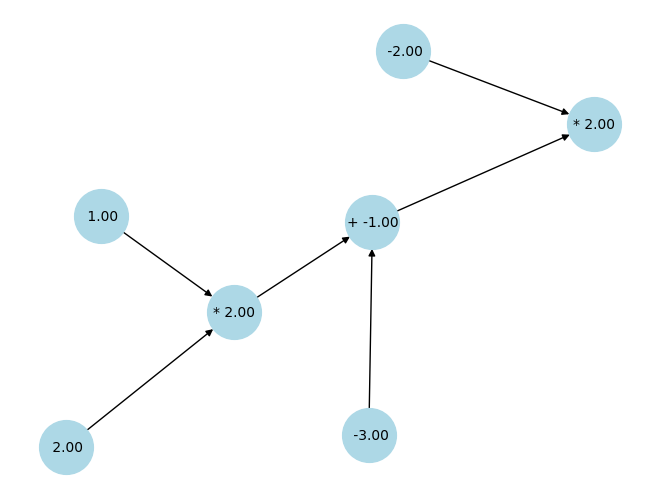

In [12]:
nx_graph = l.to_nx_graph()
pos = nx.spring_layout(nx_graph)
nx.draw(
    nx_graph, pos, with_labels=True,
    labels=nx.get_node_attributes(nx_graph, 'label'),
    node_size=1500, node_color="lightblue", font_size=10)
plt.show()

In [13]:
def backprop(a, o):
    b = 5 - 2 * a
    c = 2 * b + 3
    d = 5 * b + 6
    e = 4 * c + d * 2
    f = 2 * e
    g = 3 * f - o
    g.backward()
    for name, v in [("a", a), ("b", b), ("c", c), ("d", d), ("e", e), ("f", f), ("g", g)]:
        print(f"{name}: {v}")
    return g

a, o = Value(5.0), Value(4.0)
g = backprop(a, o)

a: Value(data=5.0000, grad=-216.0000)
b: Value(data=-5.0000, grad=108.0000)
c: Value(data=-7.0000, grad=24.0000)
d: Value(data=-19.0000, grad=12.0000)
e: Value(data=-66.0000, grad=6.0000)
f: Value(data=-132.0000, grad=3.0000)
g: Value(data=-400.0000, grad=1.0000)


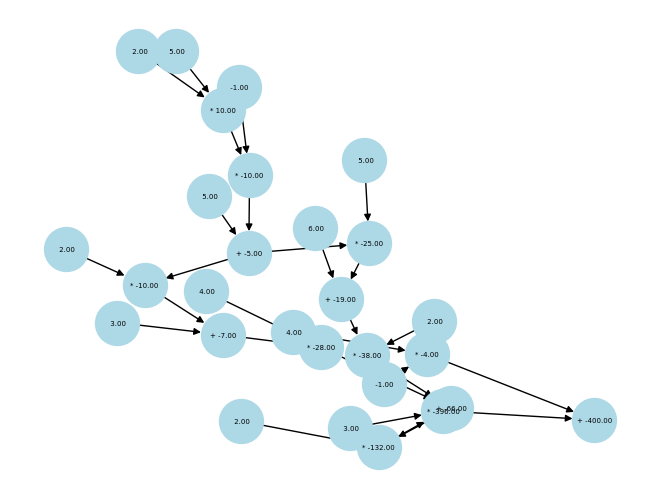

In [14]:
nx_graph = g.to_nx_graph()
pos = nx.spring_layout(nx_graph)
nx.draw(
    nx_graph, pos, with_labels=True,
    labels=nx.get_node_attributes(nx_graph, 'label'),
    node_size=1000, node_color="lightblue", font_size=5)
plt.show()

## Running the AutoGrad Engine on a Neural Net

In [15]:
import random
random.seed(0)

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = [Layer(sizes[i], sizes[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [20]:
# Classification dataset
xs = [[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]

In [21]:
model = MLP(3, [4, 4, 1])
print("number of parameters:", len(model.parameters()))

number of parameters: 41


In [36]:
loss_history = []

for step in range(50):
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
    loss_history.append(loss)

    for p in model.parameters():
        p.grad = 0.0
    loss.backward()

    for p in model.parameters():
        p.data -= 0.05 * p.grad

    if step % 10 == 0:
        print(f"step {step:2d}  loss={loss.data:.4f}")

step  0  loss=0.0043
step 10  loss=0.0039
step 20  loss=0.0037
step 30  loss=0.0034
step 40  loss=0.0032


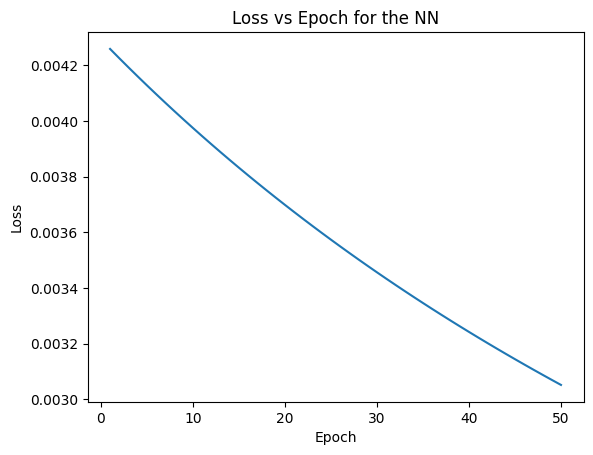

In [44]:
plt.plot(np.arange(1,51), [loss.data for loss in loss_history])
plt.title("Loss vs Epoch for the NN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [33]:
import pandas as pd
y_pred = np.array([round(model(x).data, 3) for x in xs]).reshape(-1,1)
df_data = np.concatenate((y_pred, np.array(ys).reshape(-1,1)), axis=1)
pd.DataFrame(df_data, columns=["Predicted", "Actual"])

,Predicted,Actual
0,0.964,1.0
1,-0.959,-1.0
2,-0.955,-1.0
3,0.957,1.0
